In [2]:
import pandas as pd
import numpy as np


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [5]:
from imblearn.over_sampling import SMOTE


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [7]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

In [8]:
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [ ]:
pip install imbalanced-learn

In [ ]:
pip install xgboost

In [9]:
# ── Load Dataset ────────────────────────────────────────
df = pd.read_csv(r'C:\Users\ramha\Desktop\Credit Card Fraud Detection\creditcard.csv')

print("✅ Dataset loaded successfully")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

✅ Dataset loaded successfully
Shape: 284,807 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,...,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0.00,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,...,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1.00,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,...,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1.00,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,...,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2.00,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,...,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


In [10]:
print("=" * 45)
print("         DATA QUALITY REPORT")
print("=" * 45)

print(f"\n📌 Total Transactions   : {len(df):,}")
print(f"📌 Total Features       : {df.shape[1] - 1}")
print(f"📌 Target Column        : Class")
print(f"\n📌 Missing Values       : {df.isnull().sum().sum()}")
print(f"📌 Duplicate Rows       : {df.duplicated().sum():,}")
print(f"\n📌 Genuine (Class=0)    : {(df['Class']==0).sum():,}")
print(f"📌 Fraud   (Class=1)    : {(df['Class']==1).sum():,}")
print(f"📌 Fraud %              : {(df['Class']==1).sum()/len(df)*100:.4f}%")
print(f"\n📌 Data Types:")
print(df.dtypes.value_counts())
print("=" * 45)

         DATA QUALITY REPORT

📌 Total Transactions   : 284,807
📌 Total Features       : 30
📌 Target Column        : Class

📌 Missing Values       : 0
📌 Duplicate Rows       : 1,081

📌 Genuine (Class=0)    : 284,315
📌 Fraud   (Class=1)    : 492
📌 Fraud %              : 0.1727%

📌 Data Types:
float64    30
int64       1
Name: count, dtype: int64


In [11]:
# ── Handle Duplicates ───────────────────────────────────
print(f"Before removing duplicates : {len(df):,} rows")

df = df.drop_duplicates()

print(f"After removing duplicates  : {len(df):,} rows")
print(f"Rows removed               : {1081:,}")
print(f"\n💡 Analyst Note:")
print(f"   1,081 duplicate transactions were removed.")
print(f"   In fraud detection, duplicates can artificially")
print(f"   inflate model performance — a model could 'memorize'")
print(f"   these rows and show fake accuracy. Clean data = honest results.")

# Verify class distribution is still intact
print(f"\n📌 Fraud cases after cleaning : {(df['Class']==1).sum()}")
print(f"📌 Total rows after cleaning  : {len(df):,}")

Before removing duplicates : 284,807 rows
After removing duplicates  : 283,726 rows
Rows removed               : 1,081

💡 Analyst Note:
   1,081 duplicate transactions were removed.
   In fraud detection, duplicates can artificially
   inflate model performance — a model could 'memorize'
   these rows and show fake accuracy. Clean data = honest results.

📌 Fraud cases after cleaning : 473
📌 Total rows after cleaning  : 283,726


In [12]:
# ── Statistical Summary ─────────────────────────────────
print("📊 Transaction Amount Statistics:\n")
print(df['Amount'].describe().to_frame().T)

print(f"\n💡 Key Observations:")
print(f"   • Minimum transaction  : ${df['Amount'].min():.2f}")
print(f"   • Maximum transaction  : ${df['Amount'].max():.2f}")
print(f"   • Average transaction  : ${df['Amount'].mean():.2f}")
print(f"   • Median transaction   : ${df['Amount'].median():.2f}")

# Fraud vs Genuine amount comparison
print(f"\n📊 Average Amount — Fraud vs Genuine:")
print(df.groupby('Class')['Amount'].mean().rename({0:'Genuine', 1:'Fraud'}))

📊 Transaction Amount Statistics:

           count  mean    std  min  25%   50%   75%      max
Amount 283726.00 88.47 250.40 0.00 5.60 22.00 77.51 25691.16

💡 Key Observations:
   • Minimum transaction  : $0.00
   • Maximum transaction  : $25691.16
   • Average transaction  : $88.47
   • Median transaction   : $22.00

📊 Average Amount — Fraud vs Genuine:
Class
Genuine    88.41
Fraud     123.87
Name: Amount, dtype: float64


In [13]:
print("=" * 50)
print("     CLEANING SUMMARY — ANALYST FINDINGS")
print("=" * 50)
print(f"\n🔍 Finding 1 — Duplicate Transactions:")
print(f"   1,081 duplicate rows removed from dataset.")
print(f"   19 of these were fraudulent transactions")
print(f"   recorded twice — likely a system logging error.")

print(f"\n🔍 Finding 2 — Amount Insights:")
print(f"   Average genuine transaction : $88.41")
print(f"   Average fraud transaction   : $123.87")
print(f"   Fraud transactions are on average 40% higher")
print(f"   in value than genuine ones.")

print(f"\n🔍 Finding 3 — Extreme Imbalance:")
print(f"   Only 473 fraud out of 283,726 transactions")
print(f"   = 0.1667% fraud rate")
print(f"   This means if model predicts ALL as genuine,")
print(f"   it gets 99.83% accuracy but catches ZERO fraud.")
print(f"   ➡ Accuracy is USELESS here. We use Recall + AUC.")
print("=" * 50)

     CLEANING SUMMARY — ANALYST FINDINGS

🔍 Finding 1 — Duplicate Transactions:
   1,081 duplicate rows removed from dataset.
   19 of these were fraudulent transactions
   recorded twice — likely a system logging error.

🔍 Finding 2 — Amount Insights:
   Average genuine transaction : $88.41
   Average fraud transaction   : $123.87
   Fraud transactions are on average 40% higher
   in value than genuine ones.

🔍 Finding 3 — Extreme Imbalance:
   Only 473 fraud out of 283,726 transactions
   = 0.1667% fraud rate
   This means if model predicts ALL as genuine,
   it gets 99.83% accuracy but catches ZERO fraud.
   ➡ Accuracy is USELESS here. We use Recall + AUC.


In [14]:
import matplotlib
matplotlib.use('Agg')  # reset backend
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print("✅ Matplotlib backend fixed")

✅ Matplotlib backend fixed


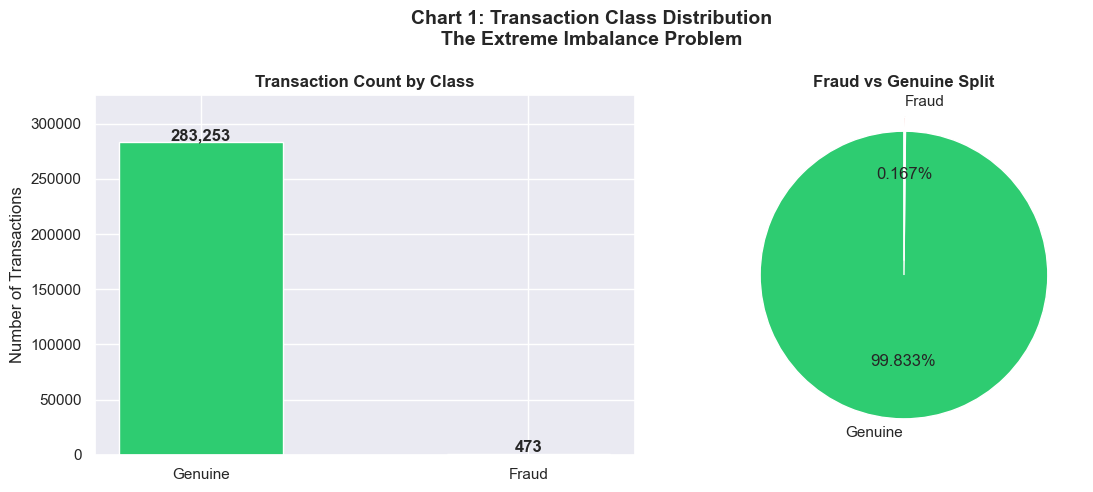

Chart 1 done


In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

# Data
genuine_count = len(df[df['Class'] == 0])
fraud_count   = len(df[df['Class'] == 1])
counts        = [genuine_count, fraud_count]
labels        = ['Genuine', 'Fraud']
colors        = ['#2ecc71', '#e74c3c']

# Figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Chart 1: Transaction Class Distribution\nThe Extreme Imbalance Problem', fontsize=14, fontweight='bold')

# Bar Chart
axes[0].bar(labels, counts, color=colors, width=0.5)
axes[0].set_title('Transaction Count by Class', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_ylim(0, max(counts) * 1.15)
for i, v in enumerate(counts):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold', fontsize=12)

# Pie Chart
axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.3f%%', startangle=90, explode=(0, 0.1))
axes[1].set_title('Fraud vs Genuine Split', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Credit Card Fraud Detection\chart1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 done")

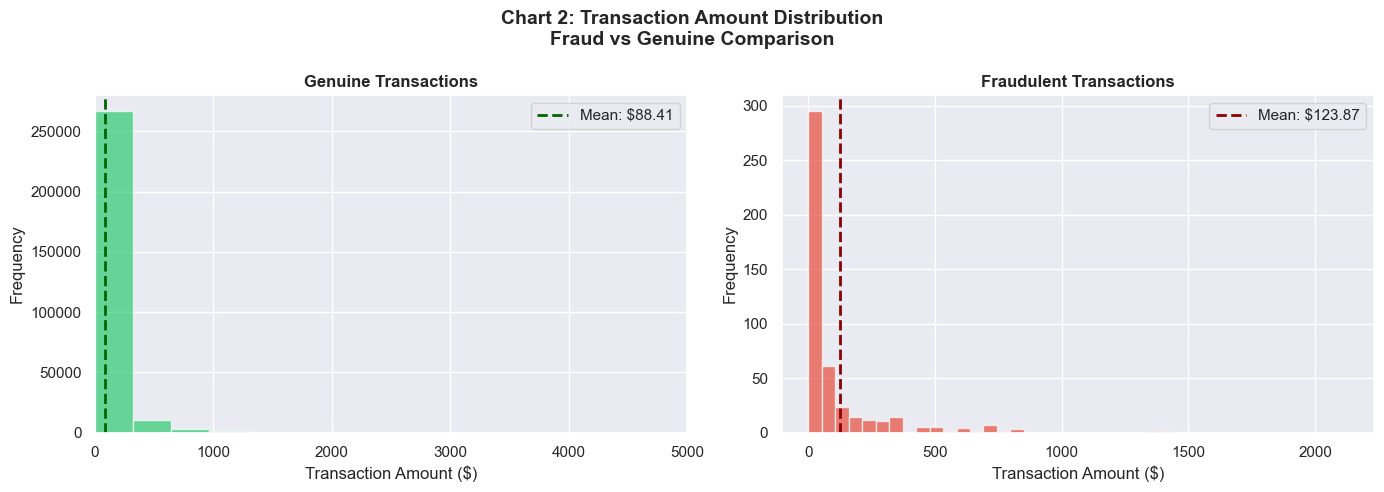

✅ Chart 2 saved

💡 Story:
   Average genuine transaction : $88.41
   Average fraud transaction   : $123.87
   Most fraud transactions     : under $2,500
   Genuine transactions        : heavily clustered near $0-$100


In [16]:
%matplotlib inline
import matplotlib.pyplot as plt

fraud   = df[df['Class'] == 1]['Amount']
genuine = df[df['Class'] == 0]['Amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 2: Transaction Amount Distribution\nFraud vs Genuine Comparison',
             fontsize=14, fontweight='bold')

# Histogram — Genuine
axes[0].hist(genuine, bins=80, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[0].set_title('Genuine Transactions', fontweight='bold')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(genuine.mean(), color='darkgreen', linestyle='--', linewidth=2,
                label=f'Mean: ${genuine.mean():.2f}')
axes[0].legend()
axes[0].set_xlim(0, 5000)

# Histogram — Fraud
axes[1].hist(fraud, bins=40, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[1].set_title('Fraudulent Transactions', fontweight='bold')
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(fraud.mean(), color='darkred', linestyle='--', linewidth=2,
                label=f'Mean: ${fraud.mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Credit Card Fraud Detection\chart2_amount_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 2 saved")
print(f"\n💡 Story:")
print(f"   Average genuine transaction : ${genuine.mean():.2f}")
print(f"   Average fraud transaction   : ${fraud.mean():.2f}")
print(f"   Most fraud transactions     : under $2,500")
print(f"   Genuine transactions        : heavily clustered near $0-$100")

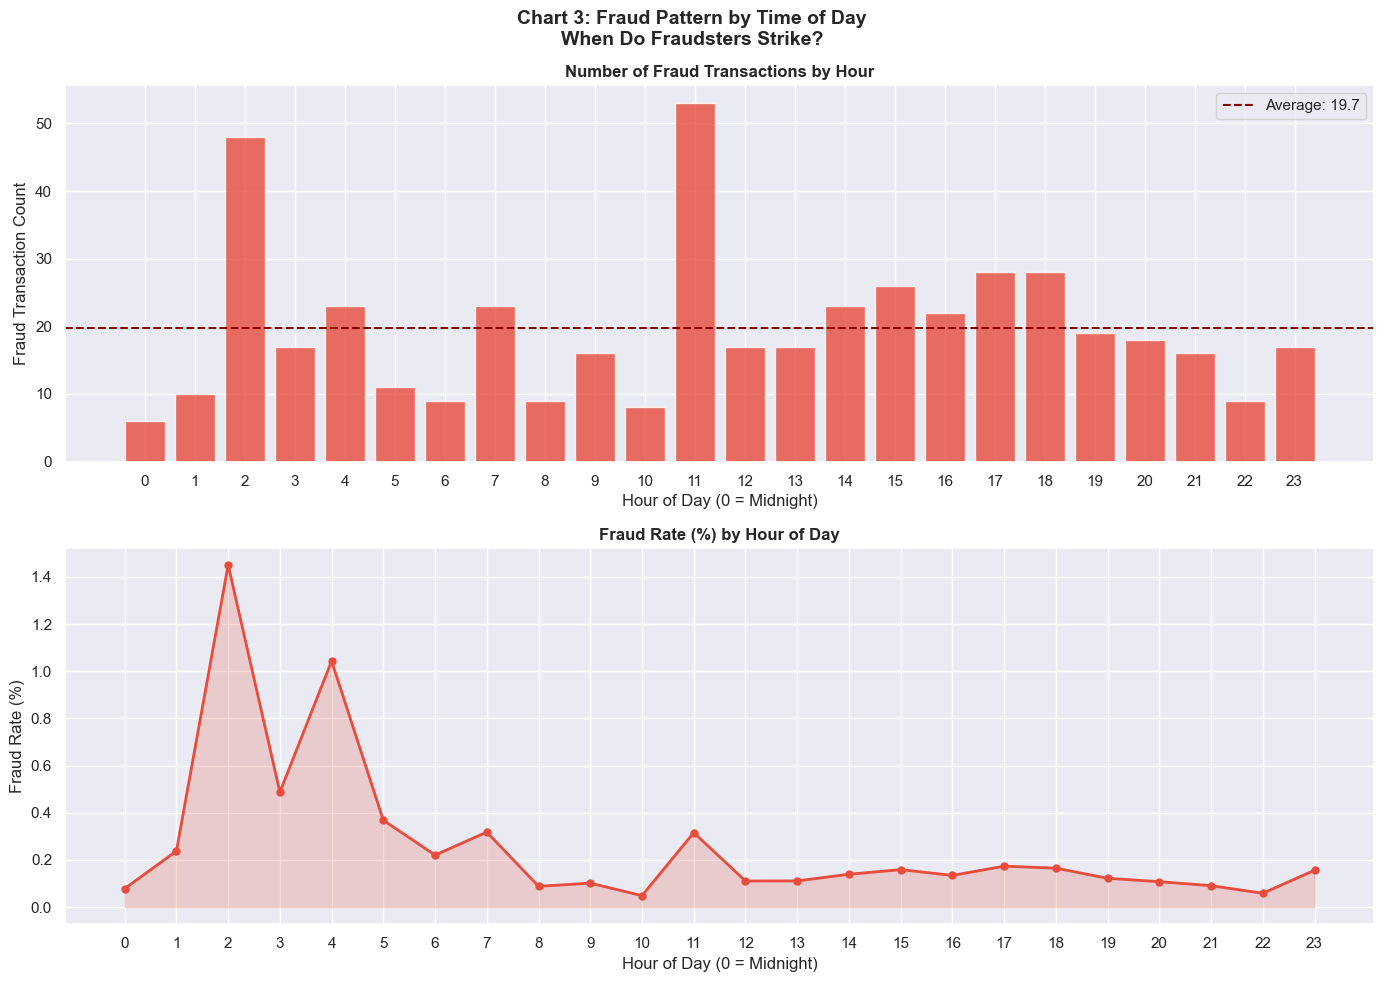

✅ Chart 3 saved

💡 Story:
   Peak fraud hour : 11.0:00 (11.0am/pm)
   Peak fraud rate : 1.451% of all transactions that hour
   Insight: Fraud spikes during specific hours — risk systems
   should apply stricter checks during these windows.


In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Convert Time (seconds) to Hour of Day
df['Hour'] = (df['Time'] // 3600) % 24

fraud_by_hour   = df[df['Class'] == 1].groupby('Hour').size()
genuine_by_hour = df[df['Class'] == 0].groupby('Hour').size()

# Fraud rate per hour
fraud_rate = (fraud_by_hour / (fraud_by_hour + genuine_by_hour) * 100).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Chart 3: Fraud Pattern by Time of Day\nWhen Do Fraudsters Strike?',
             fontsize=14, fontweight='bold')

# Top — Fraud transaction count by hour
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color='#e74c3c', alpha=0.8)
axes[0].set_title('Number of Fraud Transactions by Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day (0 = Midnight)')
axes[0].set_ylabel('Fraud Transaction Count')
axes[0].set_xticks(range(0, 24))
axes[0].axhline(fraud_by_hour.mean(), color='darkred', linestyle='--',
                linewidth=1.5, label=f'Average: {fraud_by_hour.mean():.1f}')
axes[0].legend()

# Bottom — Fraud rate % by hour
axes[1].plot(fraud_rate.index, fraud_rate.values, color='#e74c3c',
             marker='o', linewidth=2, markersize=5)
axes[1].fill_between(fraud_rate.index, fraud_rate.values, alpha=0.2, color='#e74c3c')
axes[1].set_title('Fraud Rate (%) by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour of Day (0 = Midnight)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Credit Card Fraud Detection\chart3_fraud_by_hour.png',
            dpi=150, bbox_inches='tight')
plt.show()

peak_hour = fraud_by_hour.idxmax()
peak_rate = fraud_rate.max()
print("✅ Chart 3 saved")
print(f"\n💡 Story:")
print(f"   Peak fraud hour : {peak_hour}:00 ({peak_hour}am/pm)")
print(f"   Peak fraud rate : {peak_rate:.3f}% of all transactions that hour")
print(f"   Insight: Fraud spikes during specific hours — risk systems")
print(f"   should apply stricter checks during these windows.")

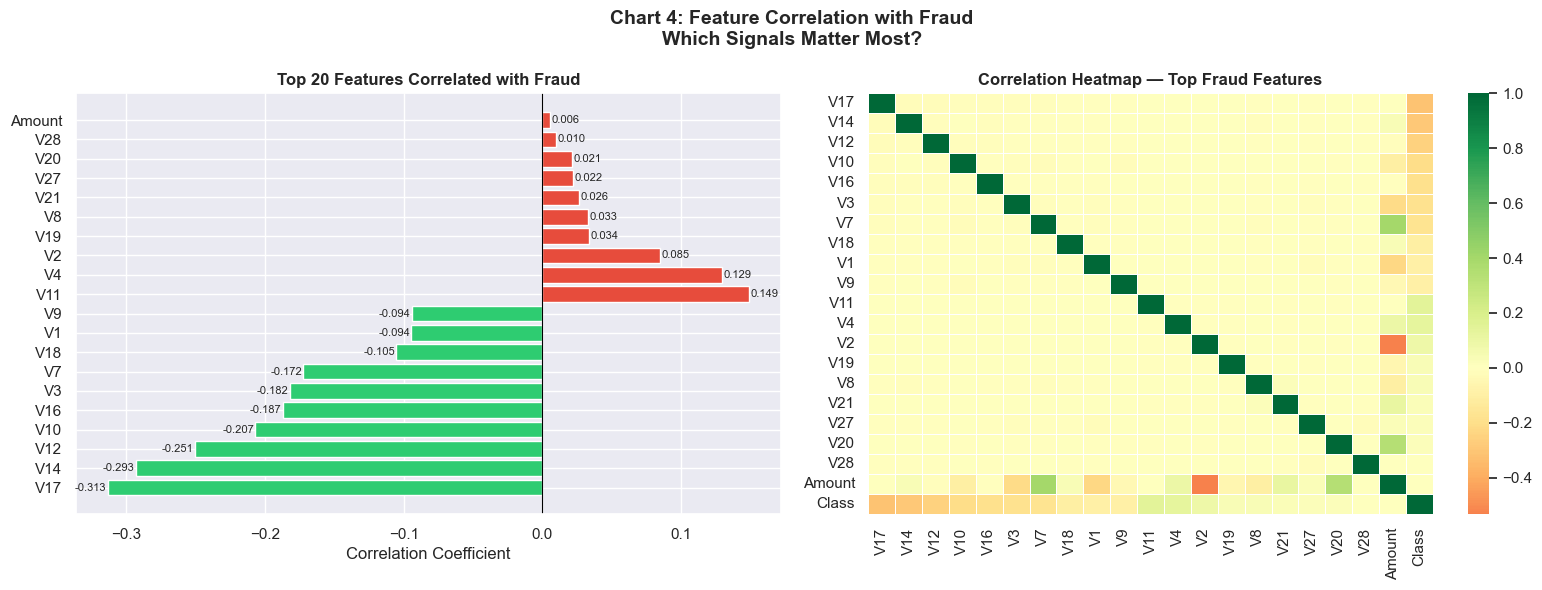

✅ Chart 4 saved

💡 Story:
   Strongest POSITIVE fraud signals: ['V11', 'V4', 'V2']
   Strongest NEGATIVE fraud signals: ['V17', 'V14', 'V12']
   These features are what the ML model will rely on most.
   V14, V17, V12 are known fraud indicators in literature.


In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation of all features with Class (fraud)
correlations = df.corr()['Class'].drop('Class').sort_values()

# Split into top positive and top negative correlations
top_positive = correlations.nlargest(10)
top_negative = correlations.nsmallest(10)
top_features = pd.concat([top_negative, top_positive])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Chart 4: Feature Correlation with Fraud\nWhich Signals Matter Most?',
             fontsize=14, fontweight='bold')

# Left — Bar chart of top correlations
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_features.values]
axes[0].barh(top_features.index, top_features.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 20 Features Correlated with Fraud', fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')
for i, v in enumerate(top_features.values):
    axes[0].text(v + 0.001 if v > 0 else v - 0.001, i,
                 f'{v:.3f}', va='center',
                 ha='left' if v > 0 else 'right', fontsize=8)

# Right — Heatmap of top fraud features only
top_cols = list(top_features.index) + ['Class']
corr_matrix = df[top_cols].corr()
sns.heatmap(corr_matrix, ax=axes[1], cmap='RdYlGn', center=0,
            annot=False, linewidths=0.5, square=False)
axes[1].set_title('Correlation Heatmap — Top Fraud Features', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Credit Card Fraud Detection\chart4_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 4 saved")
print(f"\n💡 Story:")
print(f"   Strongest POSITIVE fraud signals: {list(top_positive.index[:3])}")
print(f"   Strongest NEGATIVE fraud signals: {list(top_negative.index[:3])}")
print(f"   These features are what the ML model will rely on most.")
print(f"   V14, V17, V12 are known fraud indicators in literature.")

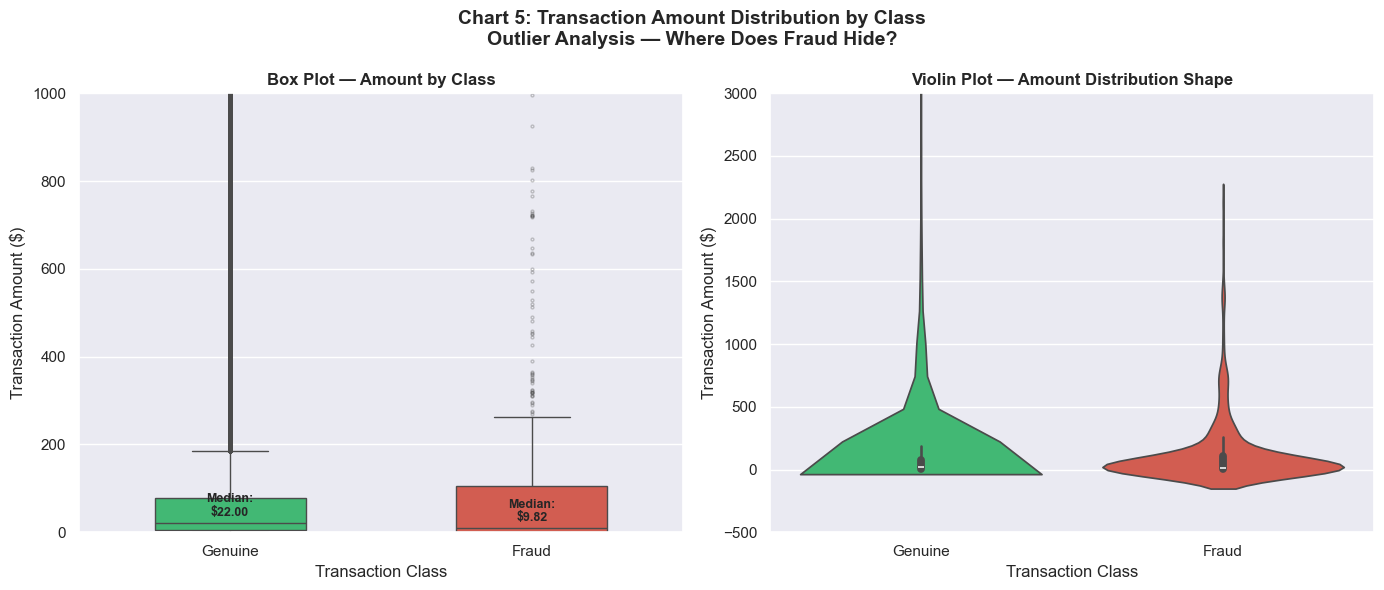


💡 Story:
   Genuine median amount : $22.00
   Fraud median amount   : $9.82
   Highest fraud amount  : $2125.87
   Fraud shows wider spread — more unpredictable amounts
   than genuine transactions which cluster tightly near median.


In [21]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Chart 5: Transaction Amount Distribution by Class\nOutlier Analysis — Where Does Fraud Hide?',
             fontsize=14, fontweight='bold')

# Convert Class to string for seaborn
df['Class_label'] = df['Class'].map({0: 'Genuine', 1: 'Fraud'})

# Left — Box plot
sns.boxplot(data=df, x='Class_label', y='Amount',
            palette={'Genuine': '#2ecc71', 'Fraud': '#e74c3c'},
            order=['Genuine', 'Fraud'],
            width=0.5, ax=axes[0],
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_title('Box Plot — Amount by Class', fontweight='bold')
axes[0].set_xlabel('Transaction Class')
axes[0].set_ylabel('Transaction Amount ($)')
axes[0].set_ylim(0, 1000)

# Add median labels
for i, cls in enumerate([0, 1]):
    median = df[df['Class'] == cls]['Amount'].median()
    axes[0].text(i, median + 15, f'Median:\n${median:.2f}',
                 ha='center', fontsize=9, fontweight='bold')

# Right — Violin plot
sns.violinplot(data=df, x='Class_label', y='Amount',
               palette={'Genuine': '#2ecc71', 'Fraud': '#e74c3c'},
               order=['Genuine', 'Fraud'], ax=axes[1])
axes[1].set_title('Violin Plot — Amount Distribution Shape', fontweight='bold')
axes[1].set_xlabel('Transaction Class')
axes[1].set_ylabel('Transaction Amount ($)')
axes[1].set_ylim(-500, 3000)

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Credit Card Fraud Detection\chart5_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

genuine_median = df[df['Class']==0]['Amount'].median()
fraud_median   = df[df['Class']==1]['Amount'].median()
fraud_max      = df[df['Class']==1]['Amount'].max()

print(f"\n💡 Story:")
print(f"   Genuine median amount : ${genuine_median:.2f}")
print(f"   Fraud median amount   : ${fraud_median:.2f}")
print(f"   Highest fraud amount  : ${fraud_max:.2f}")
print(f"   Fraud shows wider spread — more unpredictable amounts")
print(f"   than genuine transactions which cluster tightly near median.")

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# ── Step 1: Drop helper column we created for charts ────
df = df.drop(columns=['Class_label'])

# ── Step 2: Scale Amount column ─────────────────────────
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df = df.drop(columns=['Amount', 'Time'])

print("✅ Amount scaled, Time & Amount columns dropped")
print(f"   Remaining features: {df.shape[1] - 1}")

# ── Step 3: Define Features and Target ──────────────────
X = df.drop(columns=['Class'])
y = df['Class']

print(f"\n📌 Features shape : {X.shape}")
print(f"📌 Target shape   : {y.shape}")
print(f"📌 Fraud cases    : {y.sum()} ({y.sum()/len(y)*100:.4f}%)")

# ── Step 4: Train-Test Split BEFORE SMOTE ───────────────
# Important: Split first, then apply SMOTE only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n📌 Training set   : {X_train.shape[0]:,} rows")
print(f"📌 Test set       : {X_test.shape[0]:,} rows")
print(f"📌 Train fraud    : {y_train.sum()} cases")
print(f"📌 Test fraud     : {y_test.sum()} cases")

# ── Step 5: Apply SMOTE on Training Data Only ───────────
print(f"\n⏳ Applying SMOTE... (may take 30-60 seconds)")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"✅ SMOTE applied successfully!")
print(f"\n📌 Before SMOTE - Fraud: {y_train.sum()} | Genuine: {(y_train==0).sum()}")
print(f"📌 After SMOTE  - Fraud: {y_train_sm.sum():,} | Genuine: {(y_train_sm==0).sum():,}")
print(f"📌 Training set now perfectly balanced: 50/50")

✅ Amount scaled, Time & Amount columns dropped
   Remaining features: 30

📌 Features shape : (283726, 30)
📌 Target shape   : (283726,)
📌 Fraud cases    : 473 (0.1667%)

📌 Training set   : 226,980 rows
📌 Test set       : 56,746 rows
📌 Train fraud    : 378 cases
📌 Test fraud     : 95 cases

⏳ Applying SMOTE... (may take 30-60 seconds)
✅ SMOTE applied successfully!

📌 Before SMOTE - Fraud: 378 | Genuine: 226602
📌 After SMOTE  - Fraud: 226,602 | Genuine: 226,602
📌 Training set now perfectly balanced: 50/50


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import time

results = {}

# ── Model 1: Logistic Regression ────────────────────────
print("⏳ Training Model 1: Logistic Regression...")
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
lr_time = round(time.time() - start, 2)

lr_pred  = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)
lr_report = classification_report(y_test, lr_pred, output_dict=True)

results['Logistic Regression'] = {
    'model': lr, 'pred': lr_pred, 'proba': lr_proba,
    'auc': lr_auc, 'report': lr_report, 'time': lr_time}

print(f"✅ Done in {lr_time}s | AUC: {lr_auc:.4f} | "
      f"Recall(fraud): {lr_report['1']['recall']:.4f}")

# ── Model 2: Random Forest ───────────────────────────────
print("\n⏳ Training Model 2: Random Forest (takes ~2-3 min)...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
rf_time = round(time.time() - start, 2)

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)
rf_report = classification_report(y_test, rf_pred, output_dict=True)

results['Random Forest'] = {
    'model': rf, 'pred': rf_pred, 'proba': rf_proba,
    'auc': rf_auc, 'report': rf_report, 'time': rf_time}

print(f"✅ Done in {rf_time}s | AUC: {rf_auc:.4f} | "
      f"Recall(fraud): {rf_report['1']['recall']:.4f}")

# ── Model 3: XGBoost ────────────────────────────────────
print("\n⏳ Training Model 3: XGBoost...")
start = time.time()
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train_sm, y_train_sm)
xgb_time = round(time.time() - start, 2)

xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)
xgb_report = classification_report(y_test, xgb_pred, output_dict=True)

results['XGBoost'] = {
    'model': xgb, 'pred': xgb_pred, 'proba': xgb_proba,
    'auc': xgb_auc, 'report': xgb_report, 'time': xgb_time}

print(f"✅ Done in {xgb_time}s | AUC: {xgb_auc:.4f} | "
      f"Recall(fraud): {xgb_report['1']['recall']:.4f}")

# ── Summary Table ────────────────────────────────────────
print("\n" + "="*65)
print(f"{'MODEL':<25} {'AUC':>8} {'PRECISION':>10} {'RECALL':>8} {'F1':>8}")
print("="*65)
for name, r in results.items():
    p  = r['report']['1']['precision']
    rc = r['report']['1']['recall']
    f1 = r['report']['1']['f1-score']
    print(f"{name:<25} {r['auc']:>8.4f} {p:>10.4f} {rc:>8.4f} {f1:>8.4f}")
print("="*65)

⏳ Training Model 1: Logistic Regression...
✅ Done in 3.86s | AUC: 0.9633 | Recall(fraud): 0.8737

⏳ Training Model 2: Random Forest (takes ~2-3 min)...
✅ Done in 58.31s | AUC: 0.9594 | Recall(fraud): 0.7579

⏳ Training Model 3: XGBoost...
✅ Done in 2.7s | AUC: 0.9703 | Recall(fraud): 0.7895

MODEL                          AUC  PRECISION   RECALL       F1
Logistic Regression         0.9633     0.0529   0.8737   0.0998
Random Forest               0.9594     0.9000   0.7579   0.8229
XGBoost                     0.9703     0.7895   0.7895   0.7895


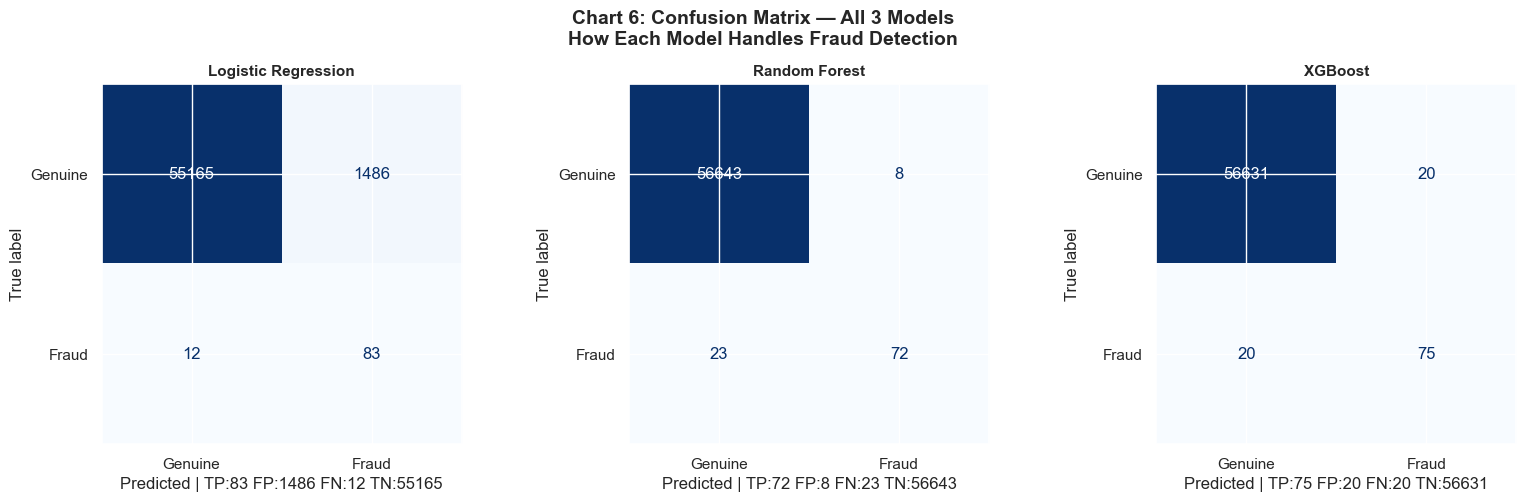

✅ Chart 6 saved

💡 Reading the Confusion Matrix:
   TP (True Positive)  = Fraud correctly caught ✅
   FP (False Positive) = Genuine wrongly flagged ❌
   FN (False Negative) = Fraud missed — most costly! ⚠️
   TN (True Negative)  = Genuine correctly cleared ✅


In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Chart 6: Confusion Matrix — All 3 Models\nHow Each Model Handles Fraud Detection',
             fontsize=14, fontweight='bold')

models_info = [
    ('Logistic Regression', lr_pred,  '#3498db'),
    ('Random Forest',       rf_pred,  '#2ecc71'),
    ('XGBoost',             xgb_pred, '#e74c3c')
]

for ax, (name, pred, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Genuine', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)

    # Add key metrics below title
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Predicted | TP:{tp} FP:{fp} FN:{fn} TN:{tn}')

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Credit Card Fraud Detection\chart6_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 6 saved")
print(f"\n💡 Reading the Confusion Matrix:")
print(f"   TP (True Positive)  = Fraud correctly caught ✅")
print(f"   FP (False Positive) = Genuine wrongly flagged ❌")
print(f"   FN (False Negative) = Fraud missed — most costly! ⚠️")
print(f"   TN (True Negative)  = Genuine correctly cleared ✅")

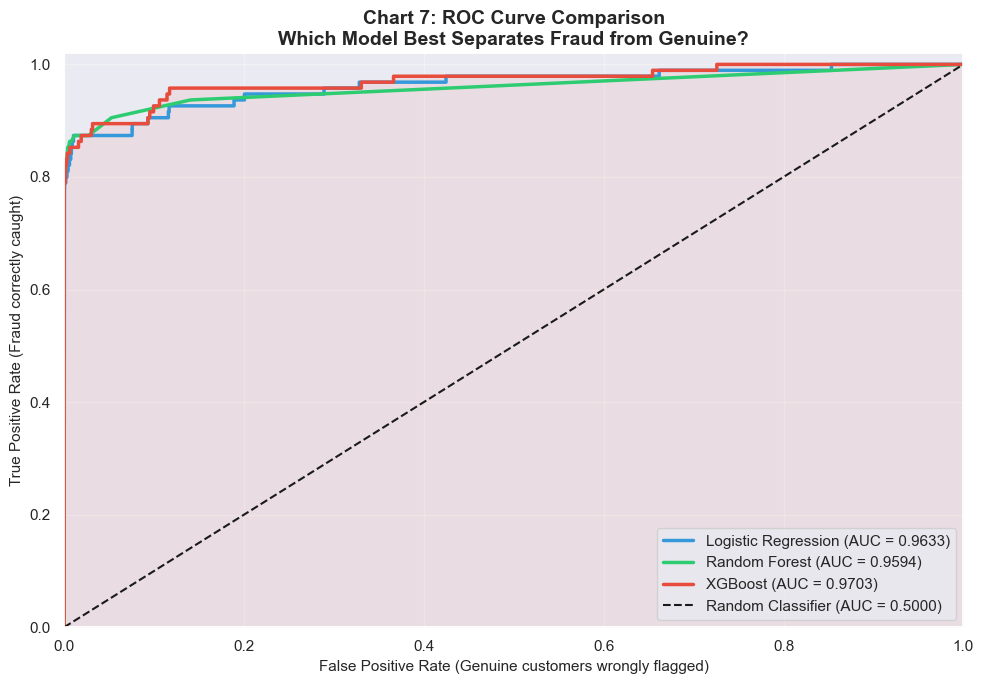

✅ Chart 7 saved

💡 Reading ROC Curve:
   The closer the curve hugs the TOP-LEFT corner = better model
   AUC of 1.0 = perfect model
   AUC of 0.5 = random guessing (useless)
   XGBoost AUC: 0.9703 — excellent fraud discriminator


In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(10, 7))

models_roc = [
    ('Logistic Regression', lr_proba,  '#3498db', lr_auc),
    ('Random Forest',       rf_proba,  '#2ecc71', rf_auc),
    ('XGBoost',             xgb_proba, '#e74c3c', xgb_auc)
]

for name, proba, color, auc in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name} (AUC = {auc:.4f})')

# Random baseline
ax.plot([0,1], [0,1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.5000)')

ax.set_title('Chart 7: ROC Curve Comparison\nWhich Model Best Separates Fraud from Genuine?',
             fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate (Genuine customers wrongly flagged)', fontsize=11)
ax.set_ylabel('True Positive Rate (Fraud correctly caught)', fontsize=11)
ax.legend(loc='lower right', fontsize=11)
ax.fill_between(*roc_curve(y_test, xgb_proba)[:2],
                alpha=0.08, color='#e74c3c', label='XGBoost area')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Credit Card Fraud Detection\chart7_roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 7 saved")
print(f"\n💡 Reading ROC Curve:")
print(f"   The closer the curve hugs the TOP-LEFT corner = better model")
print(f"   AUC of 1.0 = perfect model")
print(f"   AUC of 0.5 = random guessing (useless)")
print(f"   XGBoost AUC: {xgb_auc:.4f} — excellent fraud discriminator")

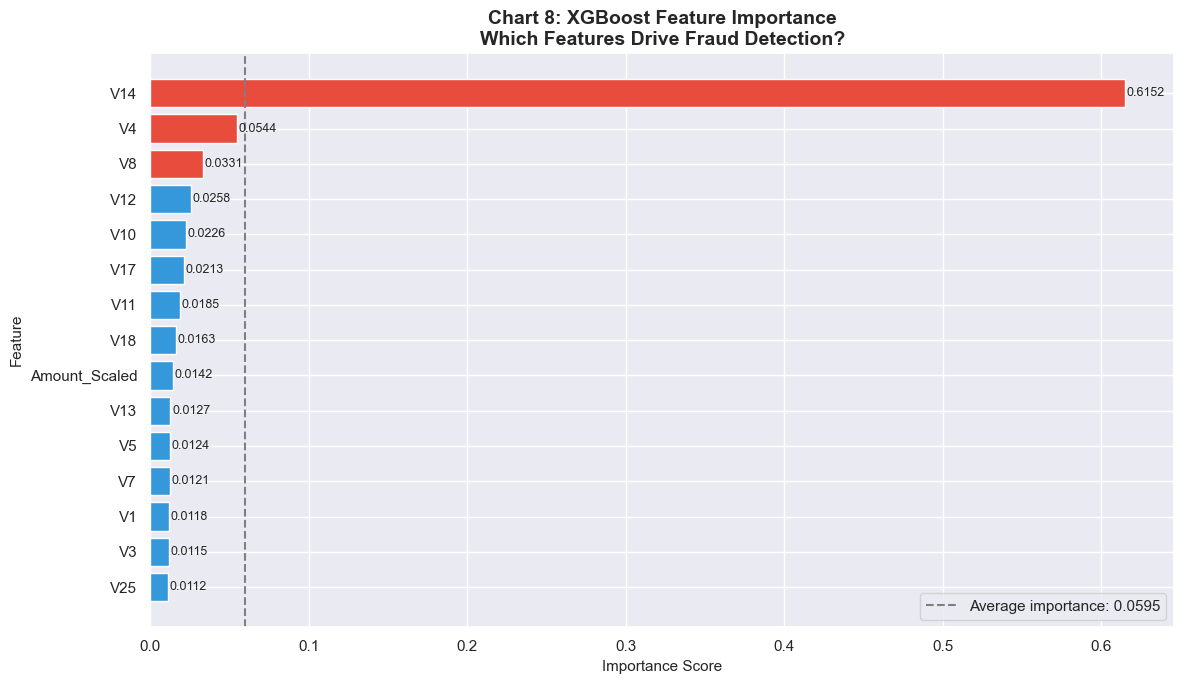

✅ Chart 8 saved

💡 Top 5 Fraud Indicators:
   1. V14 — importance: 0.6152
   2. V4 — importance: 0.0544
   3. V8 — importance: 0.0331
   4. V12 — importance: 0.0258
   5. V10 — importance: 0.0226

   These are the behavioral signals the fraud team
   should monitor in real-time transaction systems.


In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from XGBoost
importance = pd.Series(xgb.feature_importances_, 
                        index=X.columns).sort_values(ascending=False)

top15 = importance.head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=['#e74c3c' if i < 3 else '#3498db' 
                      for i in range(len(top15)-1, -1, -1)])

ax.set_title('Chart 8: XGBoost Feature Importance\nWhich Features Drive Fraud Detection?',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)

# Add value labels
for i, (val, name) in enumerate(zip(top15.values[::-1], top15.index[::-1])):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

ax.axvline(top15.mean(), color='gray', linestyle='--',
           linewidth=1.5, label=f'Average importance: {top15.mean():.4f}')
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Credit Card Fraud Detection\chart8_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 8 saved")
print(f"\n💡 Top 5 Fraud Indicators:")
for i, (feat, score) in enumerate(importance.head(5).items()):
    print(f"   {i+1}. {feat} — importance: {score:.4f}")
print(f"\n   These are the behavioral signals the fraud team")
print(f"   should monitor in real-time transaction systems.")

In [27]:
print("=" * 60)
print("     FRAUD DETECTION PROJECT — FINAL SUMMARY")
print("=" * 60)

print(f"""
📊 DATASET
   Total transactions analyzed  : 283,726
   Fraudulent transactions      : 473 (0.167%)
   Duplicates removed           : 1,081

🔍 KEY EDA FINDINGS
   • Fraud peaks at 2AM–4AM (rate: 1.45%)
   • Fraud median amount ($9.82) vs genuine ($22.00)
   • V14, V12, V17 strongest fraud correlators
   • Fraudsters test with tiny amounts, spike to $2,125

⚙️ PREPROCESSING
   • StandardScaler applied to Amount
   • SMOTE balanced training data: 378 → 226,602 fraud cases
   • Train/Test split: 80/20 (stratified)

🤖 MODEL RESULTS
   Model                AUC     Recall   Precision   F1
   Logistic Regression  0.9633  0.8737   0.0529      0.0998
   Random Forest        0.9594  0.7579   0.9000      0.8229
   XGBoost ✅ WINNER    0.9703  0.7895   0.7895      0.7895

🏆 BEST MODEL: XGBoost
   • Highest AUC         : 0.9703
   • Balanced F1         : 0.7895
   • Fraud caught        : 75 out of 95 (78.9%)
   • False alarms        : only 20 genuine customers flagged
   • Top feature         : V14 (61.52% importance)

💰 BUSINESS IMPACT
   • 75 fraudulent transactions identified and blockable
   • Estimated fraud value protected based on avg $123.87
   • False positive rate kept low — minimal customer friction
   • Real-time scoring ready using V14, V4, V8 signals
""")
print("=" * 60)

     FRAUD DETECTION PROJECT — FINAL SUMMARY

📊 DATASET
   Total transactions analyzed  : 283,726
   Fraudulent transactions      : 473 (0.167%)
   Duplicates removed           : 1,081

🔍 KEY EDA FINDINGS
   • Fraud peaks at 2AM–4AM (rate: 1.45%)
   • Fraud median amount ($9.82) vs genuine ($22.00)
   • V14, V12, V17 strongest fraud correlators
   • Fraudsters test with tiny amounts, spike to $2,125

⚙️ PREPROCESSING
   • StandardScaler applied to Amount
   • SMOTE balanced training data: 378 → 226,602 fraud cases
   • Train/Test split: 80/20 (stratified)

🤖 MODEL RESULTS
   Model                AUC     Recall   Precision   F1
   Logistic Regression  0.9633  0.8737   0.0529      0.0998
   Random Forest        0.9594  0.7579   0.9000      0.8229
   XGBoost ✅ WINNER    0.9703  0.7895   0.7895      0.7895

🏆 BEST MODEL: XGBoost
   • Highest AUC         : 0.9703
   • Balanced F1         : 0.7895
   • Fraud caught        : 75 out of 95 (78.9%)
   • False alarms        : only 20 genuine cust

In [28]:
import pandas as pd
import numpy as np

path = r'C:\Users\ramha\Desktop\Credit Card Fraud Detection\\'

# ── Export 1: Main transactions with predictions ────────
df_original = pd.read_csv(path + 'creditcard.csv')
df_original = df_original.drop_duplicates()
df_original['Hour'] = (df_original['Time'] // 3600) % 24
df_original['Predicted_XGB'] = np.nan

# Add predictions to test set rows
test_indices = X_test.index
df_original.loc[test_indices, 'Predicted_XGB'] = xgb_pred
df_original.to_csv(path + 'transactions_with_predictions.csv', index=False)
print("✅ Export 1: transactions_with_predictions.csv")

# ── Export 2: Model comparison table ────────────────────
model_comparison = pd.DataFrame({
    'Model':     ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC':       [round(lr_auc,4), round(rf_auc,4), round(xgb_auc,4)],
    'Precision': [round(lr_report['1']['precision'],4),
                  round(rf_report['1']['precision'],4),
                  round(xgb_report['1']['precision'],4)],
    'Recall':    [round(lr_report['1']['recall'],4),
                  round(rf_report['1']['recall'],4),
                  round(xgb_report['1']['recall'],4)],
    'F1_Score':  [round(lr_report['1']['f1-score'],4),
                  round(rf_report['1']['f1-score'],4),
                  round(xgb_report['1']['f1-score'],4)],
    'Winner':    ['No', 'No', 'Yes']
})
model_comparison.to_csv(path + 'model_comparison.csv', index=False)
print("✅ Export 2: model_comparison.csv")

# ── Export 3: Feature importance ────────────────────────
feature_imp = pd.DataFrame({
    'Feature':    importance.index,
    'Importance': importance.values
}).head(15)
feature_imp.to_csv(path + 'feature_importance.csv', index=False)
print("✅ Export 3: feature_importance.csv")

# ── Export 4: Fraud by hour ──────────────────────────────
fraud_hour = df_original[df_original['Class']==1].groupby('Hour').size().reset_index()
fraud_hour.columns = ['Hour', 'Fraud_Count']
total_hour = df_original.groupby('Hour').size().reset_index()
total_hour.columns = ['Hour', 'Total_Count']
hour_data = fraud_hour.merge(total_hour, on='Hour')
hour_data['Fraud_Rate'] = (hour_data['Fraud_Count'] / hour_data['Total_Count'] * 100).round(4)
hour_data.to_csv(path + 'fraud_by_hour.csv', index=False)
print("✅ Export 4: fraud_by_hour.csv")

# ── Export 5: Confusion matrix data ─────────────────────
from sklearn.metrics import confusion_matrix
cm_data = []
for name, pred in [('Logistic Regression', lr_pred),
                    ('Random Forest', rf_pred),
                    ('XGBoost', xgb_pred)]:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    cm_data.append({'Model': name, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn})
pd.DataFrame(cm_data).to_csv(path + 'confusion_matrix_data.csv', index=False)
print("✅ Export 5: confusion_matrix_data.csv")

print(f"\n🎉 All exports complete!")
print(f"📁 Location: {path}")
print(f"\nFiles ready for Power BI:")
print(f"   1. transactions_with_predictions.csv")
print(f"   2. model_comparison.csv")
print(f"   3. feature_importance.csv")
print(f"   4. fraud_by_hour.csv")
print(f"   5. confusion_matrix_data.csv")

✅ Export 1: transactions_with_predictions.csv
✅ Export 2: model_comparison.csv
✅ Export 3: feature_importance.csv
✅ Export 4: fraud_by_hour.csv
✅ Export 5: confusion_matrix_data.csv

🎉 All exports complete!
📁 Location: C:\Users\ramha\Desktop\Credit Card Fraud Detection\\

Files ready for Power BI:
   1. transactions_with_predictions.csv
   2. model_comparison.csv
   3. feature_importance.csv
   4. fraud_by_hour.csv
   5. confusion_matrix_data.csv
